In [4]:
import os
import sys
import json

from pathlib import Path
from dotenv import load_dotenv


path_proj = Path.cwd().parent
path_data = os.path.join(path_proj, "data")

load_dotenv()

sys.path.append(os.path.join(path_proj, "utils"))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
neo4j_url = os.getenv("neo4jurl")
neo4j_user = os.getenv("noe4juser")
neo4j_password = os.getenv("neo4jpass")

In [6]:
from neo4j import GraphDatabase

with GraphDatabase.driver(neo4j_url, auth=(neo4j_user, neo4j_password)) as driver:
    driver.verify_connectivity()
    print("Successfully connected to Neo4j database")

Successfully connected to Neo4j database


In [7]:
driver = GraphDatabase.driver(neo4j_url, auth=(neo4j_user, neo4j_password))

with driver.session() as session:
    result = session.run("RETURN 1 AS number")
    record = result.single()
    print(f"Test query result: {record['number']}")

Test query result: 1


In [8]:
import pandas as pd
import ast

df_llm = pd.read_csv(os.path.join(path_data, "result_analysis.csv"))

df_llm["publication_date"] = pd.to_datetime(df_llm["publication_date"])
df_llm["embedding_signal"] = df_llm["embedding_signal"].apply(ast.literal_eval)

df_llm.head()

,url,title,publication_date,classification,score,signal,justification,evidence,embedding_signal
0,https://www.federalreserve.gov/newsevents/pres...,Federal Reserve issues FOMC statement,2026-01-28,mostly_dovish,-0.5,Low job gains and a stabilizing unemployment r...,The labor market is no longer described as str...,"Job gains have remained low, and the unemploym...","[-0.039459228515625, -0.01479339599609375, -0...."
1,https://www.federalreserve.gov/newsevents/pres...,Federal Reserve issues FOMC statement,2026-01-28,mostly_dovish,-0.5,Two FOMC members dissented in favor of an imme...,"The dissents provide a direct, though minority...","Stephen I. Miran and Christopher J. Waller, wh...","[0.010986328125, -0.03143310546875, -0.0175933..."
2,https://www.federalreserve.gov/newsevents/pres...,Federal Reserve issues FOMC statement,2026-01-28,neutral,0.0,The Committee retained a data-dependent approa...,The statement does not pre-commit to either cu...,the Committee will carefully assess incoming d...,"[-0.0172576904296875, -0.0224761962890625, -0...."
3,https://www.federalreserve.gov/newsevents/pres...,Federal Reserve issues FOMC statement,2026-01-28,neutral,0.0,The Committee emphasized two-sided risks aroun...,Attention to risks on both employment and infl...,The Committee is attentive to the risks to bot...,"[0.0009055137634277344, -0.0279388427734375, -..."
4,https://www.federalreserve.gov/newsevents/pres...,Federal Reserve issues FOMC statement,2026-01-28,neutral,0.0,The Committee stated it could adjust policy in...,This is a general contingency statement rather...,prepared to adjust the stance of monetary poli...,"[-0.006946563720703125, -0.0029315948486328125..."


In [9]:
df_llm.info()

<class 'pandas.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   url               10324 non-null  str           
 1   title             10324 non-null  str           
 2   publication_date  10324 non-null  datetime64[us]
 3   classification    10324 non-null  str           
 4   score             10324 non-null  float64       
 5   signal            10324 non-null  str           
 6   justification     10324 non-null  str           
 7   evidence          10324 non-null  str           
 8   embedding_signal  10324 non-null  object        
dtypes: datetime64[us](1), float64(1), object(1), str(6)
memory usage: 726.0+ KB


In [11]:
for ind, row in df_llm.iterrows():
    query = """
       MERGE (p:Publication {url: $url})
       SET
            p.title = $title,
            p.publication_date = $publication_date
    """

    records, summary, keys = driver.execute_query(
        query,
        parameters_={
            "url": row["url"],
            "title": row["title"],
            "publication_date": row["publication_date"].to_pydatetime(),
        }
    )

    # query = """
    #     MERGE (d:Date {date: $publication_date})
    #     """
    # records, summary, keys = driver.execute_query(
    #     query,
    #     parameters_={
    #         "publication_date": row["publication_date"].to_pydatetime(),
    #     }
    # )

    # query = """
    #     MATCH (p:Publication {url: $url})
    #     MATCH (d:Date {date: $publication_date})
    #     MERGE (p)-[:PUBLISHED_ON]->(d)
    # """
    # records, summary, keys = driver.execute_query(
    #     query,
    #     parameters_={
    #         "url": row["url"],
    #         "publication_date": row["publication_date"].to_pydatetime(),
    #     }
    # )

    query = """
        MERGE (s:Signal {text: $signal,
                         url: $url})
        SET s.classification = $classification,
            s.score = $score,
            s.justification = $justification,
            s.evidence = $evidence,
            s.embedding_signal = $embedding_signal,
            s.date = $publication_date
    """
    records, summary, keys = driver.execute_query(
        query,
        parameters_={
            "signal": row["signal"],
            "url": row["url"],
            "classification": row["classification"],
            "score": row["score"],
            "justification": row["justification"],
            "evidence": row["evidence"],
            "embedding_signal": row["embedding_signal"],
            "publication_date": row["publication_date"].to_pydatetime(),
        }
    )

    query = """
        MATCH (p:Publication {url: $url})
        MATCH (s:Signal {text: $signal,
                         url: $url})
        MERGE (p)-[:HAS_SIGNAL]->(s)
    """
    records, summary, keys = driver.execute_query(
        query,
        parameters_={
            "url": row["url"],
            "signal": row["signal"],
        }
    )
    print(f"Processed record {ind} with URL: {row['url']}")


Processed record 0 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 1 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 2 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 3 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 4 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 5 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 6 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 7 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 8 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 9 with URL: https://

In [20]:
import json
from pathlib import Path

path_proj = Path.cwd().parent
path_data = path_proj / "data"

with open(path_data / "links_text.txt", "r", encoding="utf-8") as file:
    links_text = json.load(file)

links_text[0]

{'url': 'https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm',
 'title': 'Federal Reserve issues FOMC statement',
 'text': "\ufeff\nFederal Reserve Board - Federal Reserve issues FOMC statement\nSkip to main content\nAn official website of the United States Government\nHere's how you know\nOfficial websites use .gov\nA\n.gov\nwebsite belongs to an official government organization in the United States.\nSecure .gov websites use HTTPS\nA\nlock\n(\nLock\nLocked padlock icon\n) or\nhttps://\nmeans you've safely connected to the .gov website. Share sensitive information only on official, secure websites.\nBack to Home\nBoard of Governors of the Federal Reserve System\nStay Connected\nFederal Reserve Facebook Page\nFederal Reserve Instagram Page\nFederal Reserve YouTube Page\nFederal Reserve Flickr Page\nFederal Reserve LinkedIn Page\nFederal Reserve Threads Page\nFederal Reserve X Page\nFederal Reserve Bluesky Page\nSubscribe to RSS\nSubscribe to Email\nRecent Post

In [19]:
len(links_text)

1304

In [22]:
target_title = "Federal Reserve issues FOMC statement"

dates_fomc_statement = sorted(
    {
        item.get("publication_date")
        for item in links_text
        if item.get("title") == target_title and item.get("publication_date")
    }
)

dates_fomc_statement

['2015-01-28',
 '2015-03-18',
 '2015-04-29',
 '2015-06-17',
 '2015-07-29',
 '2015-09-17',
 '2015-10-28',
 '2015-12-16',
 '2016-01-27',
 '2016-03-16',
 '2016-04-27',
 '2016-06-15',
 '2016-07-27',
 '2016-09-21',
 '2016-11-02',
 '2016-12-14',
 '2017-02-01',
 '2017-03-15',
 '2017-05-03',
 '2017-06-14',
 '2017-07-26',
 '2017-09-20',
 '2017-11-01',
 '2017-12-13',
 '2018-01-31',
 '2018-03-21',
 '2018-05-02',
 '2018-06-13',
 '2018-08-01',
 '2018-09-26',
 '2018-11-08',
 '2018-12-19',
 '2019-01-30',
 '2019-03-20',
 '2019-05-01',
 '2019-06-19',
 '2019-07-31',
 '2019-09-18',
 '2019-10-30',
 '2019-12-11',
 '2020-01-29',
 '2020-03-03',
 '2020-03-15',
 '2020-03-23',
 '2020-04-29',
 '2020-06-10',
 '2020-07-29',
 '2020-09-16',
 '2020-11-05',
 '2020-12-16',
 '2021-01-27',
 '2021-03-17',
 '2021-04-28',
 '2021-06-16',
 '2021-07-28',
 '2021-09-22',
 '2021-11-03',
 '2021-12-15',
 '2022-01-26',
 '2022-03-16',
 '2022-05-04',
 '2022-06-15',
 '2022-07-27',
 '2022-09-21',
 '2022-11-02',
 '2022-12-14',
 '2023-02-

In [ ]:
from datetime import datetime

start_date = dates_fomc_statement[0]
end_date = dates_fomc_statement[1]

print(start_date)

2015-01-28


In [10]:
FRED_key = os.getenv('api_key_FRED')
api_key = FRED_key

print(api_key)

72f7955268d6a65a486d6ca126771837


In [ ]:
import requests

def get_fred_data(id_data: str) -> pd.DataFrame:
    url = f'https://api.stlouisfed.org/fred/series/observations?series_id={id_data}&api_key={api_key}&file_type=json'
    response = requests.get(url)

    # Check to make sure the request was successful
    if response.status_code != 200:
        raise Exception('Failed to get data:', response.status_code)
    else:
        # Convert the response to a dictionary
        data = response.json()

        # Extract the 'observations' field from the data
        observations = data['observations']

        # Create a pandas DataFrame from the observations
        df = pd.DataFrame(observations)

        return df

# df_upper = get_fred_data('DFEDTARL')
# df_upper.head(5)

,realtime_start,realtime_end,date,value
0,2026-08-30,2026-08-30,2008-12-16,0.00
1,2026-08-30,2026-08-30,2008-12-17,0.00
2,2026-08-30,2026-08-30,2008-12-18,0.00
3,2026-08-30,2026-08-30,2008-12-19,0.00
4,2026-08-30,2026-08-30,2008-12-20,0.00


In [ ]:
def get_diff_federal_funds() -> pd.DataFrame:
    df_lower = get_fred_data('DFEDTARL')[["date", "value"]].copy()
    df_upper = get_fred_data('DFEDTARU')[["date", "value"]].copy()

    df_lower["date"] = pd.to_datetime(df_lower["date"])
    df_lower["value"] = df_lower["value"].astype(float)
    df_upper["date"] = pd.to_datetime(df_upper["date"])
    df_upper["value"] = df_upper["value"].astype(float)
    df_upper = df_upper.rename(columns={"value": "upper_value"})

    return df_lower.merge(df_upper, on="date", how="inner")

In [18]:
df_fred = get_diff_federal_funds()

df_fred.head(5)

,date,value
0,2008-12-16,0.0
1,2008-12-17,0.0
2,2008-12-18,0.0
3,2008-12-19,0.0
4,2008-12-20,0.0


In [23]:
statement_dates = pd.to_datetime(dates_fomc_statement).normalize()
df_fred_statement_dates = df_fred[
    df_fred["date"].dt.normalize().isin(statement_dates)
].copy()
df_fred_statement_dates

,date,value
2234,2015-01-28,0.0
2283,2015-03-18,0.0
2325,2015-04-29,0.0
2374,2015-06-17,0.0
2416,2015-07-29,0.0
...,...,...
6252,2026-01-28,3.5
6301,2026-03-18,3.5
6343,2026-04-29,3.5
6392,2026-06-17,3.5


# Rodando analises no grafo

In [37]:
from graph_utils import drop_projection

In [61]:
start_date = dates_fomc_statement[0]
end_date = dates_fomc_statement[1]

In [82]:
def drop_connections_similar():
    query = """
    MATCH ()-[r:SIMILAR_TO]-()
    DELETE r
    RETURN count(r) AS removed_relationships
    """
    records, summary, keys = driver.execute_query(query)
    print(f"{records[0]['removed_relationships']} SIMILAR_TO relationships removed")

In [83]:
def create_similar_connections(
        start_date,
        end_date,
        similarity_cutoff=0.8
        ):
    drop_connections_similar()
    drop_projection('signal-cypher')

    query = """
    MATCH (source:Signal)
    WHERE source.embedding_signal IS NOT NULL 
        AND source.date >= localdatetime($start_date)
        AND source.date < localdatetime($end_date)
    WITH gds.graph.project(
        'signal-cypher',
        source,
        null,
        {
            sourceNodeProperties: source {.embedding_signal},
            targetNodeProperties: null
        }
    ) as g
    RETURN g.graphName AS graph, g.nodeCount AS nodes, g.relationshipCount AS rels
    """
    records, summary, keys = driver.execute_query(query,
                                                parameters_= {
                                                    "start_date": start_date,
                                                    "end_date": end_date,
                                                    }
    )

            
    print(f"Created graph 'signal-cypher' with {records[0]['nodes']}")


    query = """
    CALL gds.knn.stream(
        'signal-cypher',
        {
            nodeProperties: [
                {embedding_signal: 'COSINE'}
            ],
            similarityCutoff: $similarity_cutoff,
            topK: 50,
            randomSeed: 42,
            concurrency: 1
        }
    )
    YIELD node1, node2, similarity
    WITH
        gds.util.asNode(node1) AS n1,
        gds.util.asNode(node2) AS n2,
        similarity
    WHERE elementId(n1) < elementId(n2)
    MERGE (n1)-[r:SIMILAR_TO]-(n2)
    SET r.score_similarity = similarity
    RETURN count(r) AS total_score_relationships
    """
    records, summary, keys = driver.execute_query(
        query,
        parameters_={"similarity_cutoff": similarity_cutoff},
    )
    print(f"Criadas {records[0]['total_score_relationships']} relationships SIMILAR_TO")

create_similar_connections(start_date, end_date)

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


1210 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 63
Criadas 79 relationships SIMILAR_TO


In [86]:
def run_wcc(start_date, end_date):
    graph_name = "signal-wcc"
    drop_projection(graph_name)

    query = """
    MATCH (source:Signal)
    WHERE source.embedding_signal IS NOT NULL
        AND source.date >= localdatetime($start_date)
        AND source.date < localdatetime($end_date)

    OPTIONAL MATCH (source)-[r:SIMILAR_TO]-(target:Signal)
    WHERE target.embedding_signal IS NOT NULL
        AND target.date >= localdatetime($start_date)
        AND target.date < localdatetime($end_date)

    WITH gds.graph.project(
        'signal-wcc',
        source,
        target,
        {
            sourceNodeProperties: source {.embedding_signal, .score},
            targetNodeProperties: target {.embedding_signal, .score},
            relationshipProperties: r {.score_similarity}
        }
    ) AS g
    RETURN g.graphName AS graph, g.nodeCount AS nodes, g.relationshipCount AS rels
    """
    records, summary, keys = driver.execute_query(
        query,
        parameters_={
            "start_date": start_date,
            "end_date": end_date,
        },
    )
    projection = records[0]
    print(
        f"Projection '{projection['graph']}': {projection['nodes']} nodes, "
        f"{projection['rels']} relationships"
    )

    query = """
    CALL gds.wcc.stream('signal-wcc')
    YIELD nodeId, componentId
    RETURN count(DISTINCT componentId) AS number_of_communities
    """
    records, summary, keys = driver.execute_query(query)
    number_of_communities = records[0]["number_of_communities"]
    print(f"{number_of_communities} communities")
    return number_of_communities

number_of_communities = run_wcc(start_date, end_date)

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Projection 'signal-wcc' removed
Projection 'signal-wcc': 63 nodes, 1210 relationships
1 communities


In [87]:
def refine_similarity_cutoff(
    start_date,
    end_date,
    initial_cutoff=0.8,
    step=0.01,
    min_cutoff=0.1,
):
    similarity_cutoff = initial_cutoff

    while similarity_cutoff >= min_cutoff:
        create_similar_connections(start_date, end_date, similarity_cutoff)
        number_of_communities = run_wcc(start_date, end_date)

        if number_of_communities == 1:
            print(f"Single community reached with cutoff {similarity_cutoff:.2f}")
            return similarity_cutoff

        similarity_cutoff = round(similarity_cutoff - step, 10)

    raise RuntimeError(
        "A single community was not reached before the minimum cutoff."
    )

best_similarity_cutoff = refine_similarity_cutoff(start_date, end_date)

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


1210 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 63


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'
Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassifi

Criadas 79 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 63 nodes, 158 relationships
20 communities
158 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 63


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'
Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassifi

...

Criadas 414 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 63 nodes, 828 relationships
2 communities
828 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 63


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'
Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassifi

Criadas 494 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 63 nodes, 988 relationships
2 communities
988 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 63


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Criadas 605 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 63 nodes, 1210 relationships
1 communities
Single community reached with cutoff 0.71


In [106]:
def run_pagerank():
    query = """
    CALL gds.pageRank.stream(
        'signal-wcc',
        {relationshipWeightProperty: 'score_similarity'}
    )
    YIELD nodeId, score
    RETURN
        nodeId,
        score AS page_rank,
        gds.util.asNode(nodeId).score AS node_score,
        gds.util.asNode(nodeId).date AS date
    ORDER BY page_rank DESC
    """
    records, summary, keys = driver.execute_query(query)
    return pd.DataFrame([record.data() for record in records])

pagerank_results = run_pagerank()
pagerank_results

,nodeId,page_rank,node_score,date
0,4215,2.174043,-1.0,2015-09-17T00:00:00.000000000
1,4183,1.996109,-0.5,2015-09-17T00:00:00.000000000
2,4227,1.664848,0.5,2015-09-17T00:00:00.000000000
3,4195,1.646861,-1.0,2015-10-08T00:00:00.000000000
4,4210,1.635105,0.5,2015-10-08T00:00:00.000000000
...,...,...,...,...
113,10556,0.150000,0.0,2015-10-11T00:00:00.000000000
114,10557,0.150000,0.0,2015-10-11T00:00:00.000000000
115,10563,0.150000,-1.0,2015-10-02T00:00:00.000000000
116,10570,0.150000,0.0,2015-09-30T00:00:00.000000000


In [107]:
def run_weighted_degree_centrality():
    query = """
    CALL gds.degree.stream(
        'signal-wcc',
        {relationshipWeightProperty: 'score_similarity'}
    )
    YIELD nodeId, score
    RETURN nodeId, score AS degree_centrality
    ORDER BY degree_centrality DESC
    """
    records, summary, keys = driver.execute_query(query)
    return pd.DataFrame([record.data() for record in records])

degree_centrality_results = run_weighted_degree_centrality()
degree_centrality_results

,nodeId,degree_centrality
0,4215,14.557020
1,4183,12.366850
2,4195,11.131818
3,4210,10.890168
4,4184,9.986087
...,...,...
113,10556,0.000000
114,10557,0.000000
115,10563,0.000000
116,10570,0.000000


In [108]:
def calculate_period_sentiment_score(pagerank_results, start_date, end_date):
    valid_scores = pagerank_results.dropna(
        subset=["node_score", "page_rank", "degree_centrality"]
    )

    if valid_scores.empty:
        raise ValueError("No nodes with centrality and sentiment scores are available.")

    graph_query = """
    CALL gds.graph.list()
    YIELD graphName, nodeCount, relationshipCount
    WHERE graphName = 'signal-wcc'
    RETURN nodeCount, relationshipCount
    """
    records, summary, keys = driver.execute_query(graph_query)
    graph_metrics = records[0]

    page_rank_weighted_sentiment = (
        valid_scores["node_score"] * valid_scores["page_rank"]
    ).sum() / valid_scores["page_rank"].sum()
    degree_weighted_sentiment = (
        valid_scores["node_score"] * valid_scores["degree_centrality"]
    ).sum() / valid_scores["degree_centrality"].sum()
    simple_mean_sentiment = valid_scores["node_score"].mean()

    return pd.DataFrame(
        [{
            "start_date": start_date,
            "end_date": end_date,
            "node_count": graph_metrics["nodeCount"],
            "relationship_count": graph_metrics["relationshipCount"],
            "page_rank_weighted_sentiment": page_rank_weighted_sentiment,
            "degree_weighted_sentiment": degree_weighted_sentiment,
            "simple_mean_sentiment": simple_mean_sentiment,
        }]
    )

degree_centrality_results = run_weighted_degree_centrality()
pagerank_results = pagerank_results.merge(
    degree_centrality_results,
    on="nodeId",
    how="left",
)
period_sentiment_scores = calculate_period_sentiment_score(
    pagerank_results,
    start_date,
    end_date,
)
period_sentiment_scores

,start_date,end_date,node_count,relationship_count,page_rank_weighted_sentiment,degree_weighted_sentiment,simple_mean_sentiment
0,2015-01-28,2015-03-18,118,542,-0.269381,-0.303121,-0.241525


In [109]:
def analyze_all_statement_periods(dates_fomc_statement):
    period_scores = []

    for start_date, end_date in zip(
        dates_fomc_statement[:-1],
        dates_fomc_statement[1:],
    ):
        print(f"Analyzing {start_date} to {end_date}")
        similarity_cutoff = refine_similarity_cutoff(start_date, end_date)
        pagerank_results = run_pagerank()
        degree_centrality_results = run_weighted_degree_centrality()
        centrality_results = pagerank_results.merge(
            degree_centrality_results,
            on="nodeId",
            how="left",
        )
        period_score = calculate_period_sentiment_score(
            centrality_results,
            start_date,
            end_date,
        )
        period_score["similarity_cutoff"] = similarity_cutoff
        period_scores.append(period_score)

    return pd.concat(period_scores, ignore_index=True)

all_period_sentiment_scores = analyze_all_statement_periods(dates_fomc_statement)
all_period_sentiment_scores

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Criadas 1144 relationships SIMILAR_TO
Projection 'signal-wcc' removed


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Projection 'signal-wcc': 152 nodes, 2288 relationships
2 communities
2288 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 152


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


...

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Projection 'signal-wcc': 115 nodes, 2350 relationships
2 communities
2350 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 115


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Criadas 1467 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 115 nodes, 2934 relationships
1 communities
Single community reached with cutoff 0.72


,start_date,end_date,node_count,relationship_count,page_rank_weighted_sentiment,degree_weighted_sentiment,simple_mean_sentiment,similarity_cutoff
0,2015-01-28,2015-03-18,63,1210,-0.388588,-0.423077,-0.309524,0.71
1,2015-03-18,2015-04-29,109,3798,-0.314175,-0.320588,-0.284404,0.71
2,2015-04-29,2015-06-17,73,1118,-0.299071,-0.308506,-0.267123,0.73
3,2015-06-17,2015-07-29,106,2536,-0.366963,-0.401612,-0.297170,0.74
4,2015-07-29,2015-09-17,48,778,-0.325187,-0.355758,-0.270833,0.72
...,...,...,...,...,...,...,...,...
89,2025-12-10,2026-01-28,113,1446,-0.240116,-0.216169,-0.234513,0.75
90,2026-01-28,2026-03-18,143,2652,0.042228,0.041395,0.048951,0.74
91,2026-03-18,2026-04-29,140,5840,0.273228,0.289401,0.246429,0.69
92,2026-04-29,2026-06-17,110,4068,0.257003,0.269910,0.218182,0.69


In [110]:
output_file = path_data / "period_sentiment_scores.csv"
all_period_sentiment_scores.to_csv(output_file, index=False)
print(f"Saved results to {output_file}")

Saved results to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\data\period_sentiment_scores.csv


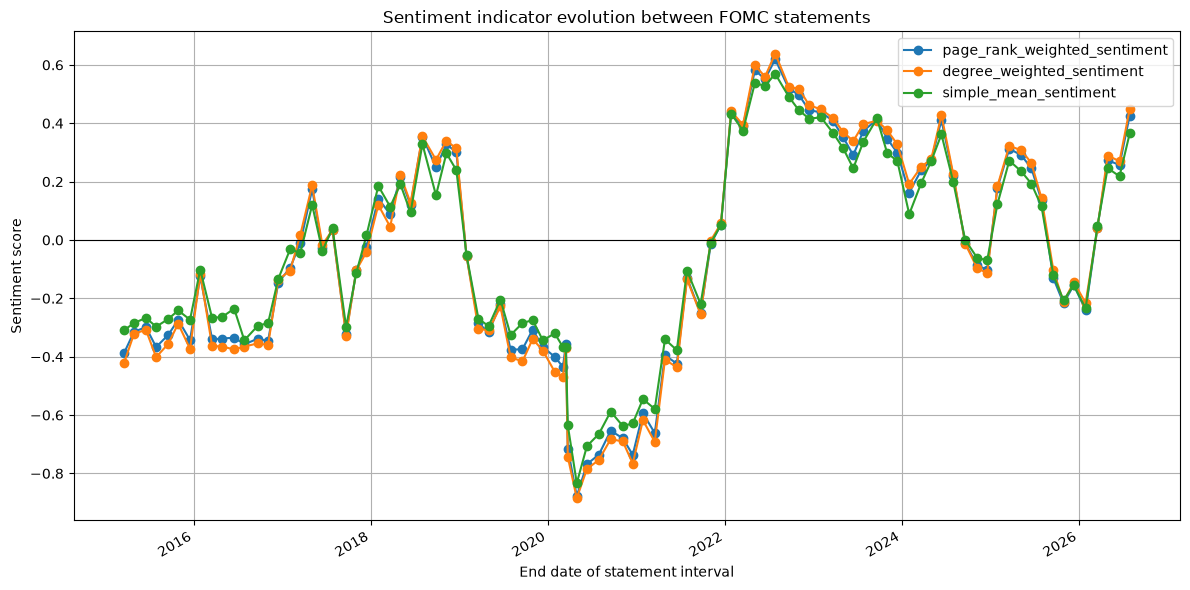

,start_date,end_date,node_count,relationship_count,page_rank_weighted_sentiment,degree_weighted_sentiment,simple_mean_sentiment,similarity_cutoff,page_rank_weighted_sentiment_change,degree_weighted_sentiment_change,simple_mean_sentiment_change
0,2015-01-28,2015-03-18,63,1210,-0.388588,-0.423077,-0.309524,0.71,NaN,NaN,NaN
1,2015-03-18,2015-04-29,109,3798,-0.314175,-0.320588,-0.284404,0.71,0.074414,0.102489,0.025120
2,2015-04-29,2015-06-17,73,1118,-0.299071,-0.308506,-0.267123,0.73,0.015104,0.012082,0.017280
3,2015-06-17,2015-07-29,106,2536,-0.366963,-0.401612,-0.297170,0.74,-0.067892,-0.093106,-0.030047
4,2015-07-29,2015-09-17,48,778,-0.325187,-0.355758,-0.270833,0.72,0.041777,0.045854,0.026336
...,...,...,...,...,...,...,...,...,...,...,...
89,2025-12-10,2026-01-28,113,1446,-0.240116,-0.216169,-0.234513,0.75,-0.085456,-0.072526,-0.079908
90,2026-01-28,2026-03-18,143,2652,0.042228,0.041395,0.048951,0.74,0.282343,0.257564,0.283464
91,2026-03-18,2026-04-29,140,5840,0.273228,0.289401,0.246429,0.69,0.231000,0.248006,0.197478
92,2026-04-29,2026-06-17,110,4068,0.257003,0.269910,0.218182,0.69,-0.016225,-0.019492,-0.028247


In [112]:
import matplotlib.pyplot as plt


def analyze_sentiment_evolution(all_period_sentiment_scores):
    sentiment_columns = [
        "page_rank_weighted_sentiment",
        "degree_weighted_sentiment",
        "simple_mean_sentiment",
    ]
    evolution = all_period_sentiment_scores.copy()
    evolution["start_date"] = pd.to_datetime(evolution["start_date"])
    evolution["end_date"] = pd.to_datetime(evolution["end_date"])
    evolution = evolution.sort_values("end_date").reset_index(drop=True)

    for column in sentiment_columns:
        evolution[f"{column}_change"] = evolution[column].diff()

    ax = evolution.plot(
        x="end_date",
        y=sentiment_columns,
        kind="line",
        marker="o",
        figsize=(12, 6),
        grid=True,
    )
    ax.set_title("Sentiment indicator evolution between FOMC statements")
    ax.set_xlabel("End date of statement interval")
    ax.set_ylabel("Sentiment score")
    ax.axhline(0, color="black", linewidth=0.8)
    plt.tight_layout()
    plt.show()

    return evolution

sentiment_evolution = analyze_sentiment_evolution(all_period_sentiment_scores)
sentiment_evolution